# Kernel-Backed Uplift Trees: Parity with the Legacy Implementation

The uplift trees in CausalML were originally a pure-Python implementation (`causalml.inference.tree.uplift`). As part of the tree-unification effort ([epic #945](https://github.com/uber/causalml/issues/945)) they are being re-grown on the shared scikit-learn `_tree` Cython kernel -- the same kernel that backs `CausalTreeRegressor` -- for speed and maintainability.

This notebook validates that the kernel rewrite **reproduces the legacy `UpliftTreeClassifier` / `UpliftRandomForestClassifier` numerically**, across every split criterion, the regularization / normalization knobs, the honest approach, and the whole forest -- and shows the kernel is faster.

> **These kernel classes are experimental and private.** They are imported here from underscore-prefixed modules (`_KernelUpliftTreeClassifier`, `_KernelUpliftRandomForestClassifier`) purely to prove parity. Keep using the public `UpliftTreeClassifier` / `UpliftRandomForestClassifier` -- the public classes will be switched over to the kernel in a later release ([#955](https://github.com/uber/causalml/issues/955)).

## Setup

In [1]:
import time
import importlib.metadata

import numpy as np
import pandas as pd

from causalml.dataset import make_uplift_classification
from causalml.inference.tree.uplift import (
    UpliftTreeClassifier,
    UpliftRandomForestClassifier,
)
# Experimental, private -- imported here only to demonstrate parity.
from causalml.inference.tree._uplift.uplifttree import _KernelUpliftTreeClassifier
from causalml.inference.tree._uplift.upliftforest import (
    _KernelUpliftRandomForestClassifier,
)

print('causalml', importlib.metadata.version('causalml'))

SEED = 42
CONTROL = 'control'

causalml 0.17.0


## Parity conditions

Bit-for-bit parity holds under two conditions, both a consequence of how each implementation searches for splits:

1. **Binary (low-cardinality) features.** The legacy tree evaluates a fixed set of percentile-based split candidates, while the kernel does an exhaustive midpoint search. On binary features the two candidate sets coincide, so the trees are identical. On continuous features the kernel considers strictly more thresholds, so the two agree closely but not exactly (shown in the last section).
2. **Depth offset.** The legacy builder counts depth from 1 and stops at `depth < max_depth`; the kernel counts from 0 and stops at `depth >= max_depth`. Identical structure therefore needs `legacy_max_depth = kernel_max_depth + 1`.

One more mapping: the legacy tree names its criterion with `evaluationFunction=`, the kernel with `criterion=`. And the legacy `.predict(X)` returns the per-group `P(Y=1 | T=g)` matrix, which is exactly what the kernel's `.predict_proba_by_group(X)` returns -- so those are what we compare.

In [2]:
LEGACY_DEPTH_OFFSET = 1  # legacy_max_depth = kernel_max_depth + 1


def make_binary_feature_data(
    n_samples=3000, n_features=5, treatment_names=('treatment1',), seed=SEED
):
    """Uplift data with binary features and heterogeneous, group-specific lifts."""
    rng = np.random.RandomState(seed)
    X = rng.randint(0, 2, size=(n_samples, n_features)).astype(np.float32)
    groups = [CONTROL, *treatment_names]
    treatment = np.array(groups)[rng.randint(0, len(groups), size=n_samples)]
    base = 0.3 + 0.1 * X[:, 1] - 0.05 * X[:, 2]
    p = base.copy()
    for i, tr in enumerate(treatment_names):
        feat = min(3 + i, n_features - 1)
        lift = 0.25 * X[:, 0] + 0.1 * X[:, feat]
        p = np.where(treatment == tr, base + lift, p)
    y = (rng.rand(n_samples) < np.clip(p, 0.0, 1.0)).astype(int)
    return X, treatment, y


def fit_tree_pair(X, treatment, y, criterion, kernel_max_depth, honesty=False,
                  **kwargs):
    """Fit the kernel tree and a structurally-matched legacy tree."""
    kern = _KernelUpliftTreeClassifier(
        criterion=criterion, control_name=CONTROL, max_depth=kernel_max_depth,
        honesty=honesty, random_state=SEED, **kwargs,
    )
    kern.fit(X, treatment, y)
    legacy = UpliftTreeClassifier(
        control_name=CONTROL, evaluationFunction=criterion,
        max_depth=kernel_max_depth + LEGACY_DEPTH_OFFSET, honesty=honesty,
        random_state=SEED, **kwargs,
    )
    legacy.fit(X, treatment, y)
    return kern, legacy


def max_proba_diff(kern, legacy, X):
    """Max absolute difference in per-group P(Y=1|T=g) over all rows/groups."""
    return float(np.abs(kern.predict_proba_by_group(X) - legacy.predict(X)).max())

## 1. Single-tree parity: KL / ED / Chi

The multi-treatment criteria (Kullback-Leibler, Euclidean, Chi-squared) on data with a control and two treatment groups. `maxdiff` is the largest absolute difference in predicted per-group probabilities between the kernel and legacy trees over every row and group -- `0` means the trees are identical.

In [3]:
X, treatment, y = make_binary_feature_data(
    n_samples=4500, n_features=6, treatment_names=('treatment1', 'treatment2'), seed=7
)

rows = []
for criterion in ['KL', 'ED', 'Chi']:
    kern, legacy = fit_tree_pair(
        X, treatment, y, criterion, kernel_max_depth=2,
        min_samples_leaf=100, min_samples_treatment=0, n_reg=0, normalization=False,
    )
    rows.append({'criterion': criterion, 'maxdiff': max_proba_diff(kern, legacy, X)})

pd.DataFrame(rows)

,criterion,maxdiff
0,KL,0.0
1,ED,0.0
2,Chi,0.0


## 2. Visualizing the tree

Issue [#953](https://github.com/uber/causalml/issues/953) taught `causalml.inference.tree.plot` to render the kernel tree: it exposes the same `fitted_uplift_tree` structure as the legacy tree, so `uplift_tree_plot` works on it unchanged. Below is the legacy tree, then the kernel tree, drawn by the same function.

They choose the **same splits** (same feature at every node), the same per-node sample counts and uplift scores, and the same leaf uplift estimates -- the structure section 1 already verified as bit-identical. Two labels are cosmetic and differ by implementation: the displayed split threshold (for a binary feature any cut in `(0, 1)` gives the same partition -- the kernel shows `0.5`, the legacy tree `0.1`) and the root-node impurity (each reports its own internal impurity scale). Rendering needs Graphviz (`dot`) on the PATH.

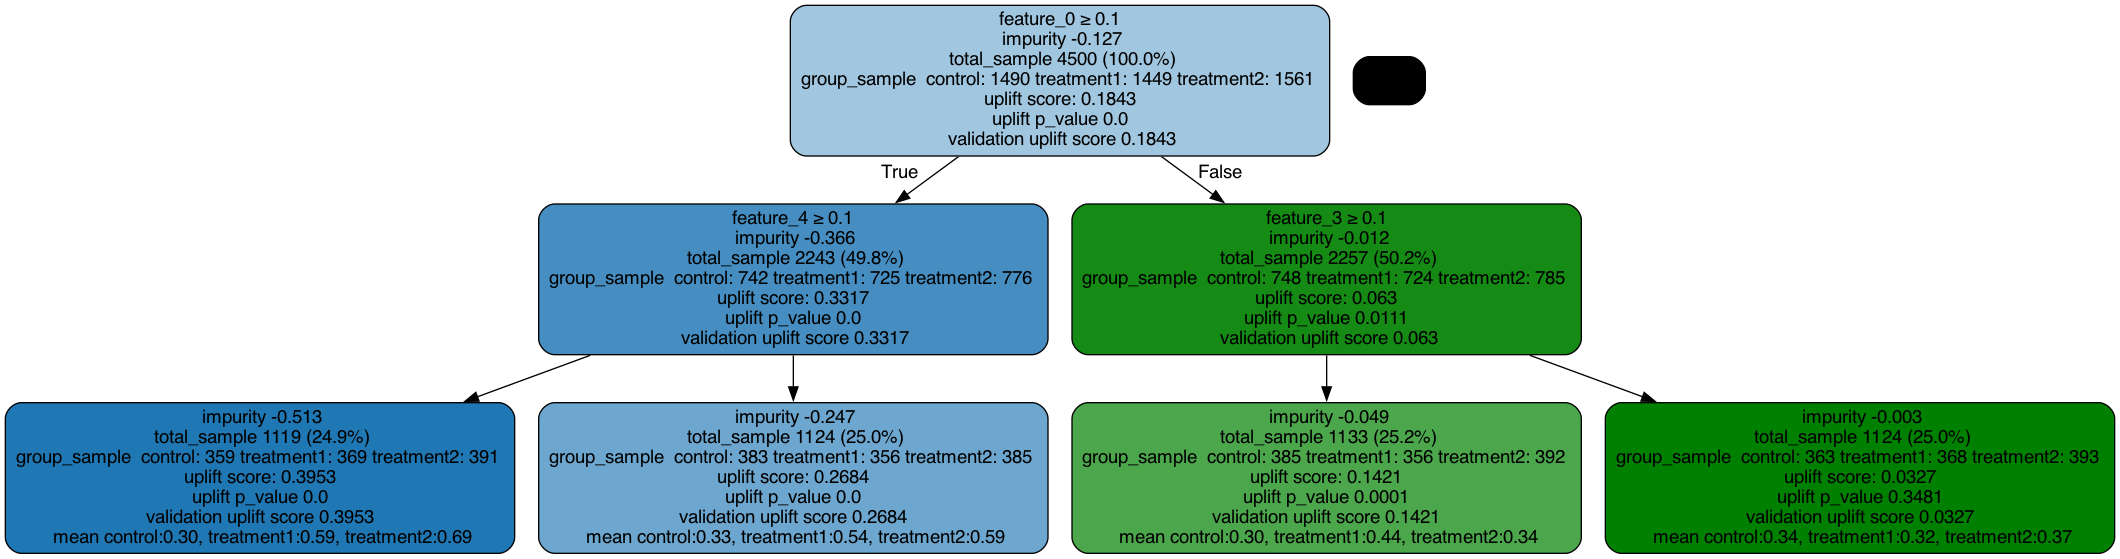

In [4]:
# Legacy UpliftTreeClassifier
from causalml.inference.tree import uplift_tree_plot
from IPython.display import Image

X, treatment, y = make_binary_feature_data(
    n_samples=4500, n_features=6, treatment_names=('treatment1', 'treatment2'), seed=7
)
kern, legacy = fit_tree_pair(
    X, treatment, y, 'KL', kernel_max_depth=2,
    min_samples_leaf=100, min_samples_treatment=0, n_reg=0, normalization=False,
)
x_names = [f'feature_{i}' for i in range(X.shape[1])]

Image(uplift_tree_plot(legacy.fitted_uplift_tree, x_names).create_png())

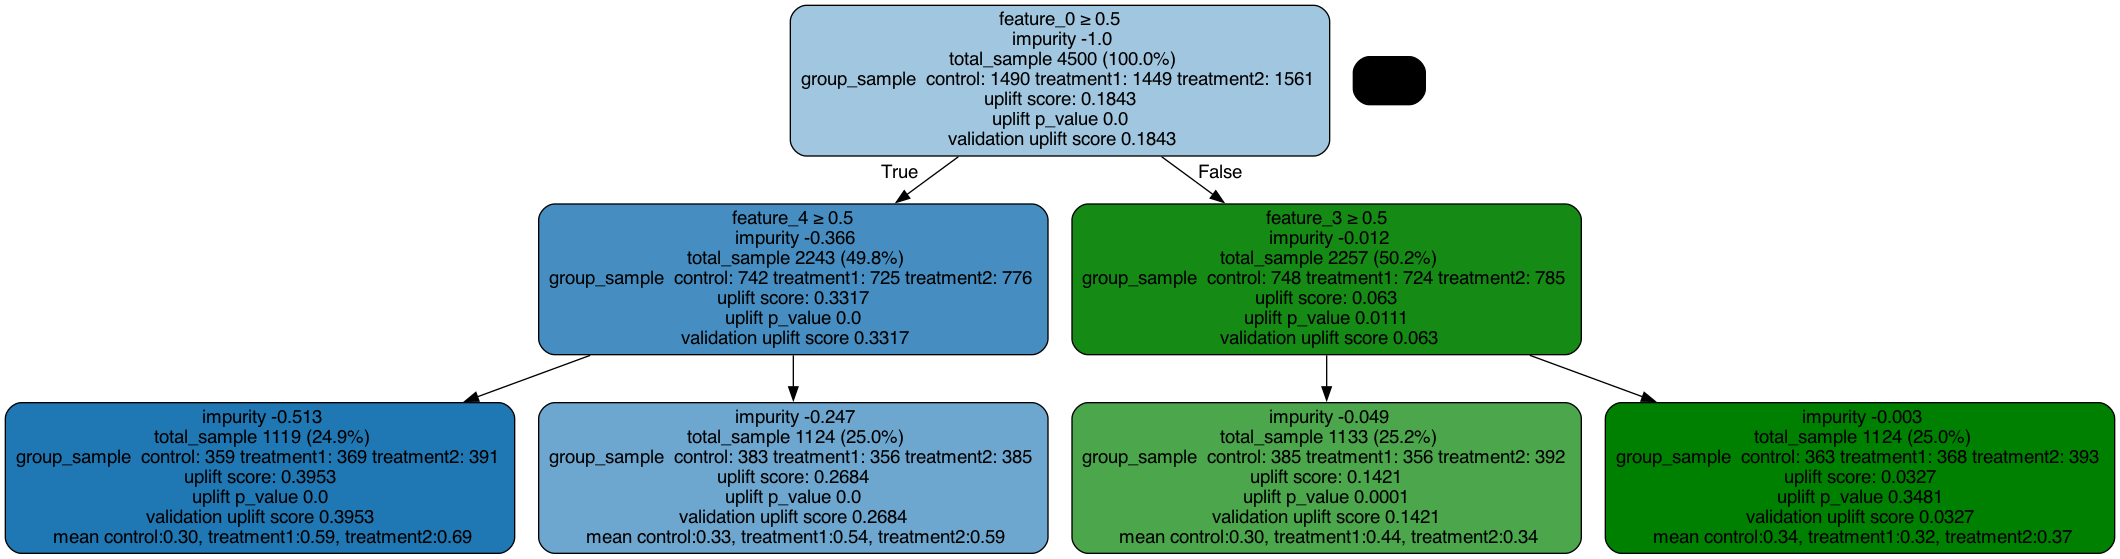

In [5]:
# Kernel _KernelUpliftTreeClassifier -- same structure, rendered by the same plot
Image(uplift_tree_plot(kern.fitted_uplift_tree, x_names).create_png())

## 3. Two-class criteria: DDP / IT / CIT / IDDP

These criteria are defined for a single treatment vs. control only. `IDDP` requires the honest approach, so the kernel tree turns honesty on automatically (and we match that on the legacy side).

In [6]:
X, treatment, y = make_binary_feature_data()

rows = []
for criterion in ['DDP', 'IT', 'CIT', 'IDDP']:
    honesty = criterion == 'IDDP'
    kern, legacy = fit_tree_pair(
        X, treatment, y, criterion, kernel_max_depth=2, honesty=honesty,
        min_samples_leaf=100, min_samples_treatment=0, n_reg=0, normalization=False,
    )
    rows.append({'criterion': criterion, 'honesty': honesty,
                 'maxdiff': max_proba_diff(kern, legacy, X)})

pd.DataFrame(rows)

,criterion,honesty,maxdiff
0,DDP,False,0.0
1,IT,False,0.0
2,CIT,False,0.0
3,IDDP,True,0.0


## 4. Regularization, normalization, and the honest approach

Parity is preserved with the Rzepakowski `n_reg` / `min_samples_treatment` regularization and `normalization` turned on, and under the honest approach (Athey & Imbens 2016), where leaf probabilities are re-estimated on a held-out split. The kernel reproduces the legacy tree's held-out split exactly.

In [7]:
X, treatment, y = make_binary_feature_data(n_samples=4000, n_features=6)

kern, legacy = fit_tree_pair(
    X, treatment, y, 'KL', kernel_max_depth=3,
    min_samples_leaf=50, min_samples_treatment=50, n_reg=100, normalization=True,
)
reg_norm = max_proba_diff(kern, legacy, X)

kern, legacy = fit_tree_pair(
    X, treatment, y, 'KL', kernel_max_depth=3, honesty=True,
    min_samples_leaf=100, min_samples_treatment=0, n_reg=0, normalization=False,
    estimation_sample_size=0.5,
)
honest = max_proba_diff(kern, legacy, X)

pd.DataFrame([
    {'config': 'KL, regularized + normalized', 'maxdiff': reg_norm},
    {'config': 'KL, honest', 'maxdiff': honest},
])

,config,maxdiff
0,"KL, regularized + normalized",0.0
1,"KL, honest",0.0


## 5. Whole-forest parity

`_KernelUpliftRandomForestClassifier` bags the kernel tree the same way `UpliftRandomForestClassifier` bags the legacy tree: per-tree seeds drawn from one parent RNG, the same bootstrap rows. With binary features, all features considered at each split (kernel `max_features=None` vs. legacy `max_features=n_features`), and the depth offset, the averaged forests match to full precision. Here `maxdiff` compares the per-treatment uplift deltas returned by `.predict(X)`.

In [8]:
X, treatment, y = make_binary_feature_data(
    n_samples=3000, n_features=6, treatment_names=('treatment1', 'treatment2')
)
n_features = X.shape[1]

rows = []
for criterion in ['KL', 'ED', 'Chi']:
    kern = _KernelUpliftRandomForestClassifier(
        control_name=CONTROL, n_estimators=5, criterion=criterion, max_depth=3,
        min_samples_leaf=100, min_samples_treatment=0, n_reg=0, normalization=False,
        max_features=None, random_state=SEED,
    )
    kern.fit(X, treatment, y)
    legacy = UpliftRandomForestClassifier(
        control_name=CONTROL, n_estimators=5, evaluationFunction=criterion,
        max_depth=3 + LEGACY_DEPTH_OFFSET, min_samples_leaf=100,
        min_samples_treatment=0, n_reg=0, normalization=False,
        max_features=n_features, random_state=SEED,
    )
    legacy.fit(X, treatment, y)
    diff = np.abs(np.asarray(kern.predict(X)) - np.asarray(legacy.predict(X))).max()
    rows.append({'criterion': criterion, 'forest_maxdiff': float(diff)})

pd.DataFrame(rows)

,criterion,forest_maxdiff
0,KL,0.0
1,ED,0.0
2,Chi,0.0


## 6. Speed

Same result, less time: the kernel grows the tree in compiled Cython instead of the legacy Python recursion. The gap widens with more samples, features, and depth.

In [9]:
X, treatment, y = make_binary_feature_data(
    n_samples=30000, n_features=10, treatment_names=('treatment1', 'treatment2')
)

t0 = time.perf_counter()
_KernelUpliftTreeClassifier(
    criterion='KL', control_name=CONTROL, max_depth=6, min_samples_leaf=100,
    random_state=SEED,
).fit(X, treatment, y)
kernel_s = time.perf_counter() - t0

t0 = time.perf_counter()
UpliftTreeClassifier(
    control_name=CONTROL, evaluationFunction='KL', max_depth=7, min_samples_leaf=100,
    random_state=SEED,
).fit(X, treatment, y)
legacy_s = time.perf_counter() - t0

print(f'kernel: {kernel_s:.3f}s   legacy: {legacy_s:.3f}s   speedup: {legacy_s / kernel_s:.1f}x')

kernel: 0.025s   legacy: 0.075s   speedup: 3.0x


## 7. Continuous features: parity is a low-cardinality property

On genuinely continuous features the kernel's exhaustive midpoint search and the legacy percentile candidates evaluate *different* sets of thresholds, so the trees pick different splits and their predictions diverge -- neither is more correct; they are just two valid fits on a finer vs. coarser split grid.

The point of this section is to show that divergence is **only** the split grid, not a discrepancy in the criterion math: take the same `make_uplift_classification` features, discretize them (a median split per column), and exact parity comes right back.

In [10]:
df, x_names = make_uplift_classification()
treatment = df['treatment_group_key'].values
y = df['conversion'].values
X_cont = df[x_names].values.astype(np.float32)
# Discretize each feature at its median -> low-cardinality, shared split grid.
X_bin = (X_cont > np.median(X_cont, axis=0)).astype(np.float32)

rows = []
for label, X in [('continuous features', X_cont), ('binarized features', X_bin)]:
    kern, legacy = fit_tree_pair(
        X, treatment, y, 'KL', kernel_max_depth=4,
        min_samples_leaf=100, min_samples_treatment=10, n_reg=10, normalization=True,
    )
    rows.append({'features': label, 'maxdiff': max_proba_diff(kern, legacy, X)})

pd.DataFrame(rows)

,features,maxdiff
0,continuous features,0.956522
1,binarized features,0.000000


## Summary

On binary-feature data with the depth offset, the kernel-backed uplift tree and forest reproduce the legacy implementation **exactly** -- across the KL / ED / Chi and DDP / IT / CIT / IDDP criteria, with regularization, normalization, and the honest approach, and for the whole forest -- while fitting faster, and it renders through the existing `plot.py` unchanged. On continuous features the two diverge, because they search different split grids; discretizing the features restores exact parity, confirming the difference is the split-candidate grid and not the criterion math.

The kernel also adds working validation-based pruning (`.prune(...)`), which the legacy tree never actually applied. The private kernel classes will replace the public `UpliftTreeClassifier` / `UpliftRandomForestClassifier` at the epic switchover ([#955](https://github.com/uber/causalml/issues/955)); until then, use the public classes.